# MNIST CNN — hand-built with `einops` / `einsum`

3-layer CNN for MNIST digit classification where **every layer is implemented
explicitly** with `einops.rearrange` / `reduce` and `einsum`:

| Layer | Implementation |
|---|---|
| `Conv2d` | zero-pad (explicit buffer) + sum of K² shifted `einsum` contractions |
| `MaxPool2d` | `rearrange` into windows + `reduce('max')` |
| `GlobalAvgPool` | `reduce('mean')` over H, W |
| `Linear` | single `einsum` contraction |
| `Flatten` | `rearrange` |

Loss and optimizer are stock PyTorch (`nn.CrossEntropyLoss`, `Adam`).
Trained here for **5 epochs** on this machine (MPS).

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
from einops import einsum, rearrange, reduce
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 0
EPOCHS = 5
BATCH_SIZE = 128
LR = 1e-3
WEIGHT_DECAY = 1e-4
DATA_DIR = "./data"

torch.manual_seed(SEED)
np.random.seed(SEED)
device = "cuda" if torch.cuda.is_available() else (
    "mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {device} | torch {torch.__version__} | einops {__import__('einops').__version__}")

device: mps | torch 2.13.0 | einops 0.8.2


## 1. Model — all layers via `einops` / `einsum`

(verbatim from `model.py`)

In [2]:
class EinsumConv2d(nn.Module):
    """Conv2d as a sum of K^2 shifted einsum contractions.

    Each kernel tap (u, v) is a rank-1 convolution:
        y_u,v[b, o, h, w] = sum_c weight[o, c, u, v] * x[b, c, h+u, w+v]
    The K^2 partial maps are summed into the final feature map.
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int = 1,
    ):
        super().__init__()
        assert kernel_size % 2 == 1, "odd kernel sizes only"
        self.kernel = kernel_size
        self.stride = stride
        self.padding = padding

        self.weight = nn.Parameter(
            torch.empty(out_channels, in_channels, kernel_size, kernel_size)
        )
        self.bias = nn.Parameter(torch.zeros(out_channels))

        fan_in = in_channels * kernel_size * kernel_size
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)  # ReLU-friendly
        bound = 1 / (fan_in**0.5)
        nn.init.uniform_(self.bias, -bound, bound)

    @staticmethod
    def _zero_pad(x: torch.Tensor, p: int) -> torch.Tensor:
        """Zero-pad the spatial dims with an explicit buffer (no F.pad)."""
        if p == 0:
            return x
        b, c, h, w = x.shape
        padded = x.new_zeros(b, c, h + 2 * p, w + 2 * p)
        padded[:, :, p : p + h, p : p + w] = x
        return padded

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C_in, H, W)
        if self.padding:
            x = self._zero_pad(x, self.padding)
        if self.stride != 1:
            x = x[..., :: self.stride, :: self.stride]

        k = self.kernel
        h_out = x.shape[-2] - k + 1
        w_out = x.shape[-1] - k + 1

        # Sum of K^2 rank-1 convolutions (one per kernel tap).
        out = None
        for u in range(k):
            for v in range(k):
                w_uv = self.weight[:, :, u, v]  # (O, C)
                x_uv = x[..., u : u + h_out, v : v + w_out]
                y_uv = einsum(x_uv, w_uv, "b c h w, o c -> b o h w")
                out = y_uv if out is None else out + y_uv

        # bias lives on the channel axis: (O,) -> (1, O, 1, 1)
        return out + rearrange(self.bias, "o -> 1 o 1 1")


class EinsumMaxPool2d(nn.Module):
    """MaxPool2d: split spatial dims into windows (einops) + reduce('max')."""

    def __init__(self, kernel_size: int = 2, stride: int = 2):
        super().__init__()
        self.kernel = kernel_size
        self.stride = stride

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # (B, C, H, W) -> (B, C, H_out, W_out, K, K) -> max over the window
        if self.stride != self.kernel:
            raise NotImplementedError("use stride == kernel (non-overlapping)")
        k = self.kernel
        windows = rearrange(x, "b c (h k) (w l) -> b c h w k l", k=k, l=k)
        return reduce(windows, "b c h w k l -> b c h w", "max")


class EinsumGlobalAvgPool2d(nn.Module):
    """Global average pooling: einops reduce('mean') over H and W."""

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return reduce(x, "b c h w -> b c 1 1", "mean")


class EinsumLinear(nn.Module):
    """Fully connected layer as a single einsum contraction."""

    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

        nn.init.kaiming_uniform_(self.weight, a=5**0.5)  # ReLU-friendly
        bound = 1 / (in_features**0.5)
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        flat = rearrange(x, "b ... -> b (...)")
        return einsum(flat, self.weight, "b i, o i -> b o") + self.bias


class MNISTCNN(nn.Module):
    """3-layer CNN for 28x28 grayscale MNIST digits.

    conv1(1->32) -> maxpool -> conv2(32->64) -> maxpool -> conv3(64->128)
    -> global avg pool -> fc(128 -> 10)

    Spatial flow: 28x28 -> 14x14 -> 7x7 -> 1x1
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.conv1 = EinsumConv2d(1, 32)
        self.pool1 = EinsumMaxPool2d(2, 2)
        self.conv2 = EinsumConv2d(32, 64)
        self.pool2 = EinsumMaxPool2d(2, 2)
        self.conv3 = EinsumConv2d(64, 128)
        self.gap = EinsumGlobalAvgPool2d()
        self.fc = EinsumLinear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 1, 28, 28)
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)
        x = torch.relu(self.conv2(x))
        x = self.pool2(x)
        x = torch.relu(self.conv3(x))
        x = self.gap(x)
        x = rearrange(x, "b c 1 1 -> b c")
        return self.fc(x)

In [3]:
model = MNISTCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"MNISTCNN ({device}): {n_params:,} parameters")

# shape check
x = torch.randn(4, 1, 28, 28, device=device)
logits = model(x)
print(f"input {tuple(x.shape)} -> logits {tuple(logits.shape)}")
assert logits.shape == (4, 10)

# numeric cross-check of the einsum ops against PyTorch references
import torch.nn.functional as F
ref = nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=True).to(device)
with torch.no_grad():
    ref.weight.copy_(model.conv1.weight); ref.bias.copy_(model.conv1.bias)
print(f"conv1 vs F.conv2d:  max abs diff = {(model.conv1(x) - ref(x)).abs().max().item():.3e}")
ref_fc = nn.Linear(128, 10).to(device)
with torch.no_grad():
    ref_fc.weight.copy_(model.fc.weight); ref_fc.bias.copy_(model.fc.bias)
feat = torch.randn(4, 128, device=device)
print(f"fc    vs F.linear:  max abs diff = {(model.fc(feat) - ref_fc(feat)).abs().max().item():.3e}")

MNISTCNN (mps): 93,962 parameters


input (4, 1, 28, 28) -> logits (4, 10)
conv1 vs F.conv2d:  max abs diff = 3.576e-07


fc    vs F.linear:  max abs diff = 0.000e+00


## 2. Data

MNIST (60,000 train / 10,000 test), standard global mean/std normalization. MNIST has no separate validation split — the official 10k test set is used for evaluation.

In [4]:
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_ds = datasets.MNIST(DATA_DIR, train=True,  download=True, transform=tfm)
test_ds  = datasets.MNIST(DATA_DIR, train=False, download=True, transform=tfm)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
print(f"train: {len(train_ds):,} | test: {len(test_ds):,} | "
      f"batches/epoch: {len(train_loader)}")

train: 60,000 | test: 10,000 | batches/epoch: 468


## 3. Training — 5 epochs

`nn.CrossEntropyLoss` + `torch.optim.Adam(lr=1e-3, weight_decay=1e-4)`. Best model (highest test-set accuracy) is kept in memory.

In [5]:
model = MNISTCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
print(f"params: {sum(p.numel() for p in model.parameters()):,} | "
      f"batch {BATCH_SIZE} | lr {LR} | wd {WEIGHT_DECAY}")

params: 93,962 | batch 128 | lr 0.001 | wd 0.0001


In [6]:
history = []
best_acc, best_state = 0.0, None
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    tot_loss, tot_n = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        tot_loss += loss.item() * x.size(0)
        tot_n += x.size(0)

    model.eval()
    vloss, correct, vn = 0.0, 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            vloss += criterion(logits, y).item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            vn += x.size(0)

    trl, vl, acc = tot_loss / tot_n, vloss / vn, 100.0 * correct / vn
    history.append(dict(epoch=epoch, train_loss=trl, val_loss=vl, val_acc=acc))
    if acc > best_acc:
        best_acc = acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    print(f"epoch {epoch}/{EPOCHS}  train_loss={trl:.4f}  val_loss={vl:.4f}  "
          f"val_acc={acc:.2f}%  ({time.time() - t0:.0f}s)")
print(f"\nbest test-split accuracy: {best_acc:.2f}%")

epoch 1/5  train_loss=0.6788  val_loss=0.2261  val_acc=93.18%  (88s)


epoch 2/5  train_loss=0.1956  val_loss=0.1407  val_acc=95.80%  (175s)


epoch 3/5  train_loss=0.1423  val_loss=0.1367  val_acc=95.92%  (263s)


epoch 4/5  train_loss=0.1138  val_loss=0.1008  val_acc=96.94%  (350s)


epoch 5/5  train_loss=0.0958  val_loss=0.0973  val_acc=96.95%  (438s)

best test-split accuracy: 96.95%


## 4. Training results

Matplotlib is building the font cache; this may take a moment.


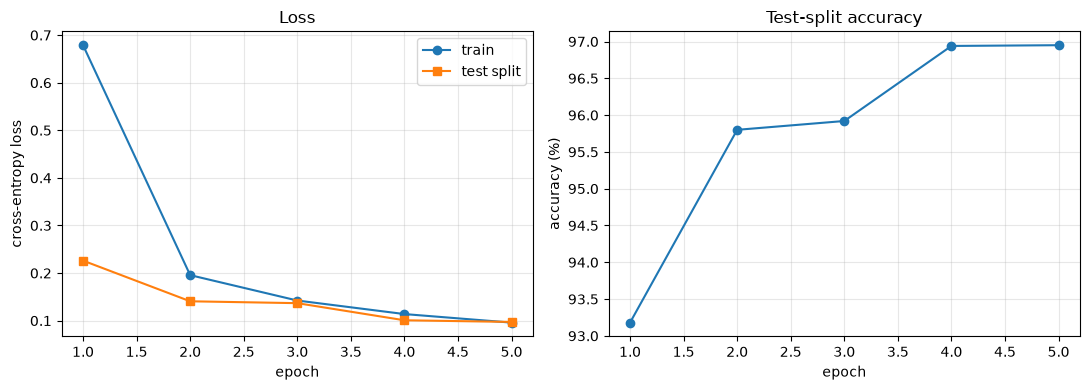

epoch,train loss,test loss,test acc
1,0.6788,0.2261,93.18%
2,0.1956,0.1407,95.80%
3,0.1423,0.1367,95.92%
4,0.1138,0.1008,96.94%
5,0.0958,0.0973,96.95%


In [7]:
import matplotlib.pyplot as plt
from IPython.display import HTML, display

ep = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ep, [h["train_loss"] for h in history], "o-", label="train")
axes[0].plot(ep, [h["val_loss"] for h in history], "s-", label="test split")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(ep, [h["val_acc"] for h in history], "o-")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy (%)")
axes[1].set_title("Test-split accuracy"); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

rows = "".join(
    f"<tr><td style='text-align:center'>{h['epoch']}</td>"
    f"<td style='text-align:right'>{h['train_loss']:.4f}</td>"
    f"<td style='text-align:right'>{h['val_loss']:.4f}</td>"
    f"<td style='text-align:right'>{h['val_acc']:.2f}%</td></tr>"
    for h in history)
display(HTML("<table border='1' cellpadding='6' cellspacing='0'>"
             "<tr style='background:#eee'><th>epoch</th><th>train loss</th>"
             "<th>test loss</th><th>test acc</th></tr>" + rows + "</table>"))

## 5. Sample predictions — 16 test images in a 4×4 grid

Best model restored; 16 random test-set samples (seed 0). **Green** = correct, **red** = wrong.

In [8]:
model.load_state_dict(best_state)
model.eval()

idx = torch.randperm(len(test_ds), generator=torch.Generator().manual_seed(SEED))[:16]
samples = [test_ds[i] for i in idx.tolist()]
imgs = torch.stack([s[0] for s in samples])
gts  = torch.tensor([s[1] for s in samples])
with torch.no_grad():
    preds = model(imgs.to(device)).argmax(1).cpu()

ok = (preds == gts)
print(f"accuracy on these 16 samples: {int(ok.sum())}/16")

accuracy on these 16 samples: 16/16


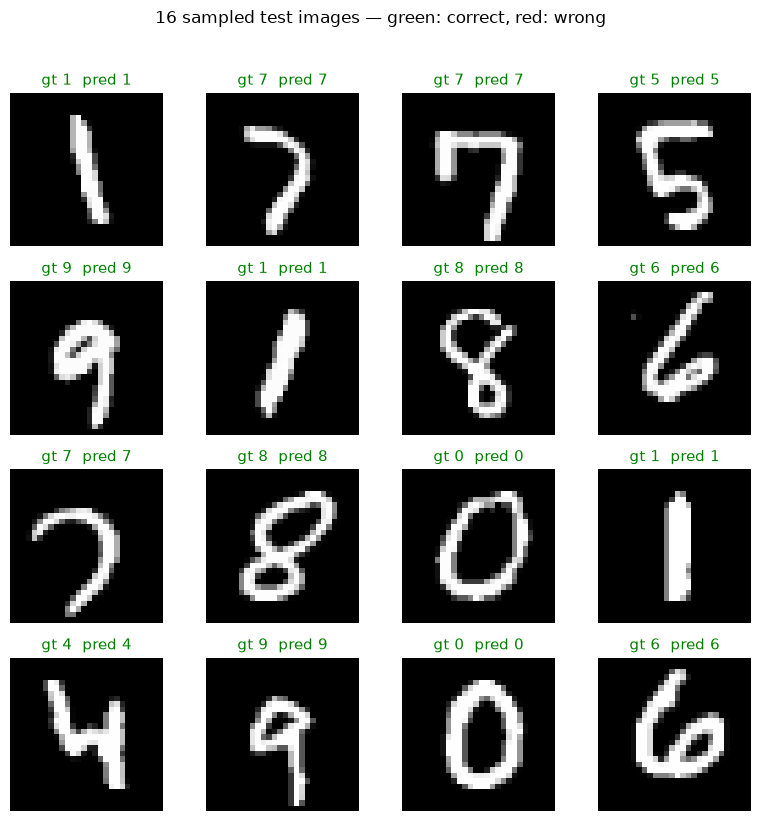

In [9]:
denorm = lambda t: t * 0.3081 + 0.1307
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, im, gt, pr, good in zip(axes.ravel(), imgs, gts, preds, ok):
    ax.imshow(denorm(im).squeeze(), cmap="gray")
    ax.set_title(f"gt {gt.item()}  pred {pr.item()}",
                 color="green" if good else "red", fontsize=11)
    ax.axis("off")
fig.suptitle("16 sampled test images — green: correct, red: wrong", y=1.02)
plt.tight_layout(); plt.show()

**Summary.** Pure `einops`/`einsum` CNN, 93,962 parameters, 5 epochs on this machine's GPU (MPS) — see the table above for per-epoch results and the best test-split accuracy. The equivalent training script is `train.py` (checkpoint: `mnist_cnn_einsum_best.pt`).